In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("players_22.csv",low_memory=False)

In [3]:
df

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,NaN,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png


In [4]:
df.drop(columns = ["club_loaned_from"],inplace=True)

In [5]:
df

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,NaN,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png


In [6]:
df.isnull().sum()

sofifa_id               0
player_url              0
short_name              0
long_name               0
player_positions        0
                    ...  
player_face_url         0
club_logo_url          61
club_flag_url          61
nation_logo_url     18480
nation_flag_url         0
Length: 109, dtype: int64

In [7]:
df.drop(columns = ["nation_position","nation_position","nation_jersey_number","player_tags","player_traits","goalkeeping_speed","nation_logo_url"],inplace=True)

In [8]:
df

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,61+3,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,61+3,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,60+3,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,62+3,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,75+3,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,48+2,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,48+2,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,47+2,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,32+2,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,https://cdn.sofifa.net/flags/ie.png


In [9]:
df.isnull().sum()

sofifa_id            0
player_url           0
short_name           0
long_name            0
player_positions     0
                    ..
gk                   0
player_face_url      0
club_logo_url       61
club_flag_url       61
nation_flag_url      0
Length: 103, dtype: int64

In [10]:
df.drop(columns = ["nation_team_id"],inplace=True)

In [11]:
df

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,61+3,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,61+3,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,60+3,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,62+3,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,75+3,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,48+2,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,48+2,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,47+2,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,32+2,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,https://cdn.sofifa.net/flags/ie.png


In [12]:
df.isnull().sum()

sofifa_id            0
player_url           0
short_name           0
long_name            0
player_positions     0
                    ..
gk                   0
player_face_url      0
club_logo_url       61
club_flag_url       61
nation_flag_url      0
Length: 102, dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,61+3,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,61+3,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,60+3,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,62+3,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,75+3,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,48+2,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,48+2,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,47+2,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,32+2,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,https://cdn.sofifa.net/flags/ie.png


In [15]:
df.isnull().sum()

sofifa_id           0
player_url          0
short_name          0
long_name           0
player_positions    0
                   ..
gk                  0
player_face_url     0
club_logo_url       0
club_flag_url       0
nation_flag_url     0
Length: 102, dtype: int64

In [16]:
df.drop(columns = ["sofifa_id","player_url","short_name","long_name","player_face_url","club_logo_url","club_flag_url","nation_flag_url","lcb","cb","rcb","gk"],inplace=True)

In [17]:
df

,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,...,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,rb
0,"RW, ST, CF",93,93,78000000.0,320000.0,34,1987-06-24,170,72,73.0,...,87+3,87+3,91+2,66+3,64+3,64+3,64+3,66+3,61+3,61+3
1,ST,92,92,119500000.0,270000.0,32,1988-08-21,185,81,21.0,...,80+3,80+3,84+3,64+3,66+3,66+3,66+3,64+3,61+3,61+3
2,"ST, LW",91,91,45000000.0,270000.0,36,1985-02-05,187,83,11.0,...,78+3,78+3,86+3,63+3,59+3,59+3,59+3,63+3,60+3,60+3
3,"LW, CAM",91,91,129000000.0,270000.0,29,1992-02-05,175,68,73.0,...,82+3,82+3,89+2,67+3,63+3,63+3,63+3,67+3,62+3,62+3
4,"CM, CAM",91,91,125500000.0,350000.0,30,1991-06-28,181,70,10.0,...,89+2,89+2,89+2,79+3,80+3,80+3,80+3,79+3,75+3,75+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,CDM,47,52,70000.0,1000.0,22,1999-01-02,180,64,112541.0,...,46+2,46+2,47+2,48+2,46+2,46+2,46+2,48+2,48+2,48+2
19235,CM,47,59,110000.0,500.0,19,2002-03-18,175,70,445.0,...,47+2,47+2,49+2,49+2,46+2,46+2,46+2,49+2,48+2,48+2
19236,CM,47,55,100000.0,500.0,21,2000-02-07,178,72,111131.0,...,47+2,47+2,48+2,47+2,46+2,46+2,46+2,47+2,47+2,47+2
19237,ST,47,60,110000.0,500.0,19,2002-04-23,173,66,111131.0,...,39+2,39+2,45+2,33+2,29+2,29+2,29+2,33+2,32+2,32+2


In [18]:
df.drop(columns=["dob","club_team_id","club_name","league_name","club_jersey_number","club_joined","club_contract_valid_until","nationality_id","nationality_name"],inplace=True)

In [19]:
df


,player_positions,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_level,club_position,...,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,rb
0,"RW, ST, CF",93,93,78000000.0,320000.0,34,170,72,1.0,RW,...,87+3,87+3,91+2,66+3,64+3,64+3,64+3,66+3,61+3,61+3
1,ST,92,92,119500000.0,270000.0,32,185,81,1.0,ST,...,80+3,80+3,84+3,64+3,66+3,66+3,66+3,64+3,61+3,61+3
2,"ST, LW",91,91,45000000.0,270000.0,36,187,83,1.0,ST,...,78+3,78+3,86+3,63+3,59+3,59+3,59+3,63+3,60+3,60+3
3,"LW, CAM",91,91,129000000.0,270000.0,29,175,68,1.0,LW,...,82+3,82+3,89+2,67+3,63+3,63+3,63+3,67+3,62+3,62+3
4,"CM, CAM",91,91,125500000.0,350000.0,30,181,70,1.0,RCM,...,89+2,89+2,89+2,79+3,80+3,80+3,80+3,79+3,75+3,75+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,CDM,47,52,70000.0,1000.0,22,180,64,1.0,SUB,...,46+2,46+2,47+2,48+2,46+2,46+2,46+2,48+2,48+2,48+2
19235,CM,47,59,110000.0,500.0,19,175,70,1.0,RES,...,47+2,47+2,49+2,49+2,46+2,46+2,46+2,49+2,48+2,48+2
19236,CM,47,55,100000.0,500.0,21,178,72,1.0,RES,...,47+2,47+2,48+2,47+2,46+2,46+2,46+2,47+2,47+2,47+2
19237,ST,47,60,110000.0,500.0,19,173,66,1.0,RES,...,39+2,39+2,45+2,33+2,29+2,29+2,29+2,33+2,32+2,32+2


In [20]:
df.to_csv("players_22_clean.csv",index=False)

In [21]:
# Fix 1 - extract first position
df["position"] = df["player_positions"].str.split(",").str[0].str.strip()
df.drop(columns=["player_positions"], inplace=True)

# Fix 2 - drop positional rating columns
pos_cols = ['ls','st','rs','lw','lf','cf','rf','rw','lam','cam',
            'ram','lm','lcm','cm','rcm','rm','lwb','ldm','cdm','rdm','rwb','lb','rb']
df.drop(columns=pos_cols, inplace=True)

In [22]:
df

,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_level,club_position,preferred_foot,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,position
0,93,93,78000000.0,320000.0,34,170,72,1.0,RW,Left,...,96,20,35,24,6,11,15,14,8,RW
1,92,92,119500000.0,270000.0,32,185,81,1.0,ST,Right,...,88,35,42,19,15,6,12,8,10,ST
2,91,91,45000000.0,270000.0,36,187,83,1.0,ST,Right,...,95,24,32,24,7,11,15,14,11,ST
3,91,91,129000000.0,270000.0,29,175,68,1.0,LW,Right,...,93,35,32,29,9,9,15,15,11,LW
4,91,91,125500000.0,350000.0,30,181,70,1.0,RCM,Right,...,89,68,65,53,15,13,5,10,13,CM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,47,52,70000.0,1000.0,22,180,64,1.0,SUB,Right,...,37,38,43,48,6,10,5,15,13,CDM
19235,47,59,110000.0,500.0,19,175,70,1.0,RES,Right,...,47,37,44,47,11,12,6,8,10,CM
19236,47,55,100000.0,500.0,21,178,72,1.0,RES,Right,...,36,38,44,48,8,6,7,10,6,CM
19237,47,60,110000.0,500.0,19,173,66,1.0,RES,Right,...,47,10,14,11,7,10,7,14,15,ST


In [23]:
df.shape

(16020, 58)

In [24]:
print(df["position"].value_counts())
print()
print(df.dtypes)

position
CB     3139
ST     2361
CM     2039
CDM    1595
LB     1294
RB     1276
CAM    1087
RM      964
LM      929
RW      465
LW      406
RWB     169
LWB     164
CF      132
Name: count, dtype: int64

overall                          int64
potential                        int64
value_eur                      float64
wage_eur                       float64
age                              int64
height_cm                        int64
weight_kg                        int64
league_level                   float64
club_position                   object
preferred_foot                  object
weak_foot                        int64
skill_moves                      int64
international_reputation         int64
work_rate                       object
body_type                       object
real_face                       object
release_clause_eur             float64
pace                           float64
shooting                       float64
passing                        float64
dribbling       

In [25]:
print(df["work_rate"].unique())
print(df["body_type"].unique())

['Medium/Low' 'High/Medium' 'High/Low' 'High/High' 'Medium/High'
 'Medium/Medium' 'Low/High' 'Low/Medium' 'Low/Low']
['Unique' 'Normal (170-185)' 'Lean (170-185)' 'Lean (185+)'
 'Normal (185+)' 'Normal (170-)' 'Lean (170-)' 'Stocky (185+)'
 'Stocky (170-185)' 'Stocky (170-)']


In [26]:
# Drop body_type
df.drop(columns=["body_type"], inplace=True)

In [27]:
# Label encode work_rate
le = LabelEncoder()
df["work_rate"] = le.fit_transform(df["work_rate"])

In [28]:
df.dtypes

overall                          int64
potential                        int64
value_eur                      float64
wage_eur                       float64
age                              int64
height_cm                        int64
weight_kg                        int64
league_level                   float64
club_position                   object
preferred_foot                  object
weak_foot                        int64
skill_moves                      int64
international_reputation         int64
work_rate                        int64
real_face                       object
release_clause_eur             float64
pace                           float64
shooting                       float64
passing                        float64
dribbling                      float64
defending                      float64
physic                         float64
attacking_crossing               int64
attacking_finishing              int64
attacking_heading_accuracy       int64
attacking_short_passing  

In [29]:
df["preferred_foot"] = df["preferred_foot"].map({"Right": 1, "Left": 0})
print(df["preferred_foot"].unique())
print(df["preferred_foot"].dtype)

[0 1]
int64


In [30]:
df["real_face"] = df["real_face"].map({"Yes": 1, "No": 0})
print(df["real_face"].unique())
print(df["real_face"].dtype)

[1 0]
int64


In [31]:
df.dtypes

overall                          int64
potential                        int64
value_eur                      float64
wage_eur                       float64
age                              int64
height_cm                        int64
weight_kg                        int64
league_level                   float64
club_position                   object
preferred_foot                   int64
weak_foot                        int64
skill_moves                      int64
international_reputation         int64
work_rate                        int64
real_face                        int64
release_clause_eur             float64
pace                           float64
shooting                       float64
passing                        float64
dribbling                      float64
defending                      float64
physic                         float64
attacking_crossing               int64
attacking_finishing              int64
attacking_heading_accuracy       int64
attacking_short_passing  

In [32]:
df.drop(columns=["club_position"], inplace=True)
print(df.shape)
print(df.dtypes.value_counts())

(16020, 56)
int64      45
float64    10
object      1
Name: count, dtype: int64


In [33]:
df

,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_level,preferred_foot,weak_foot,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,position
0,93,93,78000000.0,320000.0,34,170,72,1.0,0,4,...,96,20,35,24,6,11,15,14,8,RW
1,92,92,119500000.0,270000.0,32,185,81,1.0,1,4,...,88,35,42,19,15,6,12,8,10,ST
2,91,91,45000000.0,270000.0,36,187,83,1.0,1,4,...,95,24,32,24,7,11,15,14,11,ST
3,91,91,129000000.0,270000.0,29,175,68,1.0,1,5,...,93,35,32,29,9,9,15,15,11,LW
4,91,91,125500000.0,350000.0,30,181,70,1.0,1,5,...,89,68,65,53,15,13,5,10,13,CM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,47,52,70000.0,1000.0,22,180,64,1.0,1,3,...,37,38,43,48,6,10,5,15,13,CDM
19235,47,59,110000.0,500.0,19,175,70,1.0,1,3,...,47,37,44,47,11,12,6,8,10,CM
19236,47,55,100000.0,500.0,21,178,72,1.0,1,3,...,36,38,44,48,8,6,7,10,6,CM
19237,47,60,110000.0,500.0,19,173,66,1.0,1,3,...,47,10,14,11,7,10,7,14,15,ST


In [34]:
X = df.drop(columns=["position"])
y = df["position"]

print(X.shape)
print(y.value_counts())

(16020, 55)
position
CB     3139
ST     2361
CM     2039
CDM    1595
LB     1294
RB     1276
CAM    1087
RM      964
LM      929
RW      465
LW      406
RWB     169
LWB     164
CF      132
Name: count, dtype: int64


In [35]:
#Creating scaler
scaler = StandardScaler()

In [36]:
X_scaled = scaler.fit_transform(X)

In [37]:
X_scaled

array([[ 3.9728124 ,  3.63310657,  9.56341347, ...,  1.52275315,
         1.20416933, -0.7745928 ],
       [ 3.82635146,  3.46762213, 14.85236202, ...,  0.53506803,
        -0.7911547 , -0.11595971],
       [ 3.67989052,  3.30213769,  5.35774354, ...,  1.52275315,
         1.20416933,  0.21335683],
       ...,
       [-2.7643908 , -2.65530219, -0.36451645, ..., -1.11107383,
        -0.12604669, -1.43322589],
       [-2.7643908 , -1.82787998, -0.36324201, ..., -1.11107383,
         1.20416933,  1.53062301],
       [-2.7643908 , -1.82787998, -0.36324201, ...,  0.8642964 ,
        -0.45860069,  1.20130646]])

In [38]:
#Create thresholder
#thresholder = VarianceThreshold(threshold=0.5)
thresholder = VarianceThreshold(threshold=0)

In [39]:
X_High_Variance = thresholder.fit_transform(X_scaled)

In [40]:
X_High_Variance

array([[ 3.9728124 ,  3.63310657,  9.56341347, ...,  1.52275315,
         1.20416933, -0.7745928 ],
       [ 3.82635146,  3.46762213, 14.85236202, ...,  0.53506803,
        -0.7911547 , -0.11595971],
       [ 3.67989052,  3.30213769,  5.35774354, ...,  1.52275315,
         1.20416933,  0.21335683],
       ...,
       [-2.7643908 , -2.65530219, -0.36451645, ..., -1.11107383,
        -0.12604669, -1.43322589],
       [-2.7643908 , -1.82787998, -0.36324201, ..., -1.11107383,
         1.20416933,  1.53062301],
       [-2.7643908 , -1.82787998, -0.36324201, ...,  0.8642964 ,
        -0.45860069,  1.20130646]])

In [41]:
X_High_Variance.shape

(16020, 55)

In [42]:
binary_cols = [col for col in X.columns if X[col].nunique() == 2]
print(binary_cols)

['preferred_foot', 'real_face']


In [43]:
X_binary = X[binary_cols]

thresholder_binary = VarianceThreshold(threshold=0.8 * (1 - 0.8))
X_binary_high_var = thresholder_binary.fit_transform(X_binary)

print("Before:", X_binary.shape)
print("After:", X_binary_high_var.shape)

# Check the variance of each binary column
for col in binary_cols:
    p = X[col].mean()
    print(f"{col}: p={p:.3f}, variance={p*(1-p):.3f}")

Before: (16020, 2)
After: (16020, 1)
preferred_foot: p=0.747, variance=0.189
real_face: p=0.116, variance=0.102


In [44]:
X = X.drop(columns=["real_face"])
print(X.shape)

(16020, 54)


In [45]:
X

,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_level,preferred_foot,weak_foot,...,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,93,93,78000000.0,320000.0,34,170,72,1.0,0,4,...,75,96,20,35,24,6,11,15,14,8
1,92,92,119500000.0,270000.0,32,185,81,1.0,1,4,...,90,88,35,42,19,15,6,12,8,10
2,91,91,45000000.0,270000.0,36,187,83,1.0,1,4,...,88,95,24,32,24,7,11,15,14,11
3,91,91,129000000.0,270000.0,29,175,68,1.0,1,5,...,93,93,35,32,29,9,9,15,15,11
4,91,91,125500000.0,350000.0,30,181,70,1.0,1,5,...,83,89,68,65,53,15,13,5,10,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,47,52,70000.0,1000.0,22,180,64,1.0,1,3,...,42,37,38,43,48,6,10,5,15,13
19235,47,59,110000.0,500.0,19,175,70,1.0,1,3,...,44,47,37,44,47,11,12,6,8,10
19236,47,55,100000.0,500.0,21,178,72,1.0,1,3,...,39,36,38,44,48,8,6,7,10,6
19237,47,60,110000.0,500.0,19,173,66,1.0,1,3,...,49,47,10,14,11,7,10,7,14,15


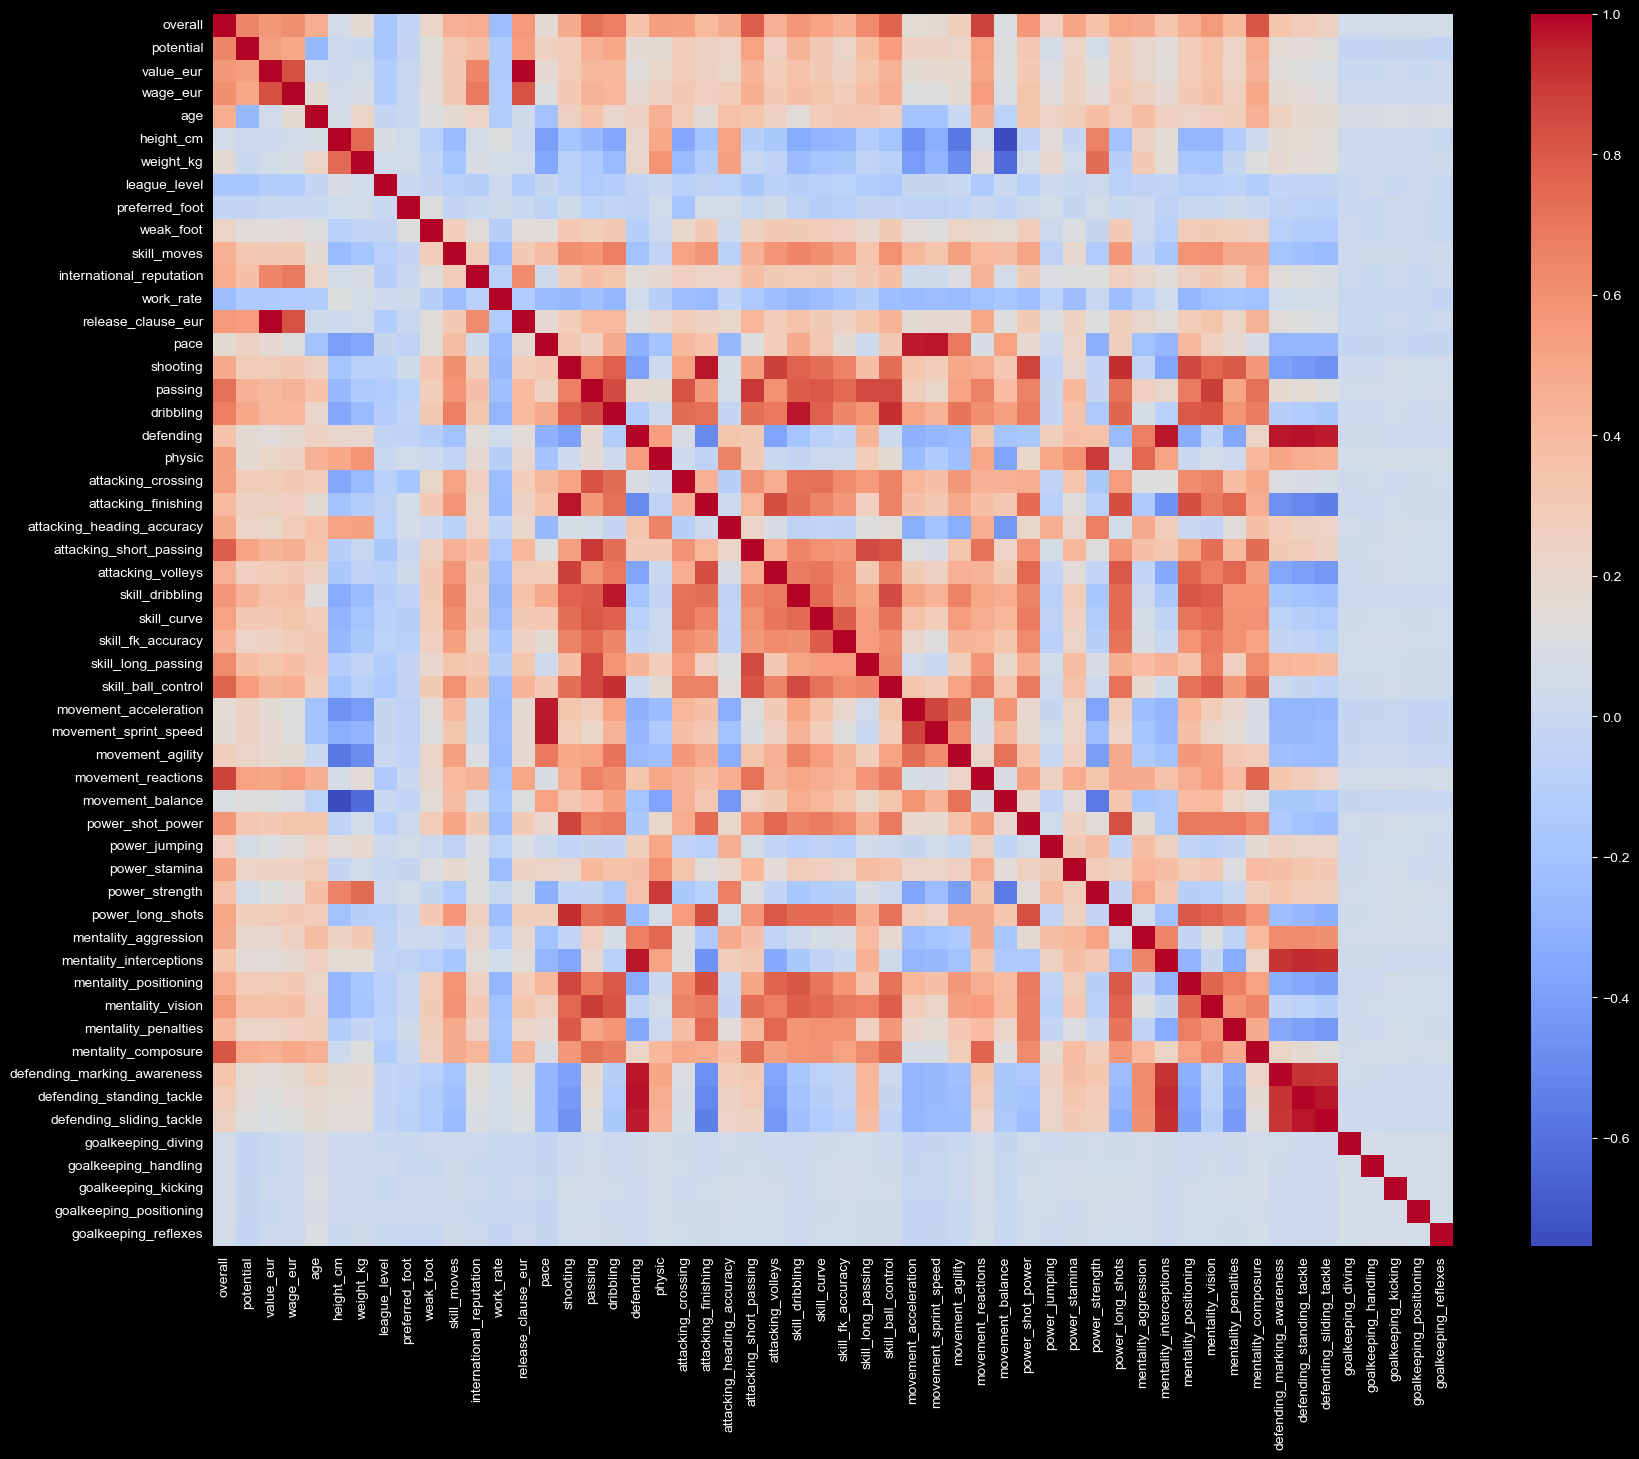

In [46]:
corr_matrix = X.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

In [47]:
# Find highly correlated pairs
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns with correlation > 0.85
to_drop = [col for col in upper_triangle.columns
           if any(upper_triangle[col] > 0.85)]

print("Columns to drop:", to_drop)
print("Count:", len(to_drop))

Columns to drop: ['release_clause_eur', 'attacking_finishing', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_reactions', 'power_shot_power', 'power_strength', 'power_long_shots', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle']
Count: 18


In [48]:
X = X.drop(columns=to_drop)
print(X.shape)

(16020, 36)


In [49]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(y_encoded[:5])
print(le.classes_)

[11 13 13  7  4]
['CAM' 'CB' 'CDM' 'CF' 'CM' 'LB' 'LM' 'LW' 'LWB' 'RB' 'RM' 'RW' 'RWB' 'ST']


In [50]:
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X, y_encoded)

print("Before:", X.shape)
print("After:", X_selected.shape)

# See which features were selected
selected_features = X.columns[selector.get_support()]
print("\nSelected features:")
print(selected_features.tolist())

Before: (16020, 36)
After: (16020, 20)

Selected features:
['height_cm', 'weight_kg', 'preferred_foot', 'skill_moves', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_heading_accuracy', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'movement_agility', 'movement_balance', 'power_jumping', 'mentality_aggression', 'mentality_penalties']


In [51]:
scaler = StandardScaler()
X_selected_df = X[selected_features]
X_selected_scaled = scaler.fit_transform(X_selected_df)

model = LogisticRegression(max_iter=5000)
rfecv = RFECV(estimator=model, cv=5, scoring="accuracy")
rfecv.fit(X_selected_scaled, y_encoded)

print("Optimal number of features:", rfecv.n_features_)
print("Selected features:", X_selected_df.columns[rfecv.support_].tolist())

Optimal number of features: 20
Selected features: ['height_cm', 'weight_kg', 'preferred_foot', 'skill_moves', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_heading_accuracy', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'movement_agility', 'movement_balance', 'power_jumping', 'mentality_aggression', 'mentality_penalties']
